In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%ls

drive/  sample_data/


In [ ]:
%pwd

'/content'

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Repertorio/Prop. Fisicas de Sol')

In [ ]:
%ls

# Molécula de Monoxido de carbono (${\rm CO}$)

El cuaderno de trabajo ilustra el cálculo de los niveles de energía vibraciones y niveles de energía rotaciones de una molécula diatómica.

In [ ]:
# Instalación de la librería pyscf
%%capture
!pip install pyscf

In [ ]:
# Importación de las librerías
#---
from pylab import * # Librerías numpy,scipy y matplotlib
import pyscf        # Librería pyscf
from pyscf import scf

## Geometría de la molécula diatómica ${\rm CO}$

|Átomo| X[Å] | Y[Å] | Z[Å] |
|-|-|-|-|
C|0.0000|0.0000|0.0000|
O|0.0000|0.0000|1.1280|


In [ ]:
# Definición de la clase mole (molecule)
# útil para manipular los parámetros
# y atributos de las integrales GTO.
CO = pyscf.gto.Mole(atom = """
    C 0.0000  0.0000 0.0000
    O 0.0000  0.0000 1.1280
    """,spin=0,basis = "STO-3G")
# ¿Qué significa base STO-3G?
# https://en.wikipedia.org/wiki/STO-nG_basis_sets

# Definimos la molécula con la geometría
CO = CO.build()
# y ahora puede calcularse la energía U

In [ ]:
# Definimos el método de cálculo con la geometría
rhf = scf.RHF(CO)
# ¿Qué significa RHF?
# Restricted Hartree Fock
# https://en.wikipedia.org/wiki/Hartree%E2%80%93Fock_method

# Ejecuta el método definido y regresa la
# Energía convergida.
rhf.kernel()

# Las unidades de la energia son Hartree
# 1 Hartree = 27.211 eV

# Los Hartree son las unidades atomicas de la energía

converged SCF energy = -111.224558695609


np.float64(-111.22455869560908)

## Variación de la separación entre los núcleos

In [ ]:
R = 3.0 # angstroms
CO = pyscf.gto.Mole(atom = f"""
    C 0.0000  0.0000 0.0000
    O 0.0000  0.0000 {R}
    """,spin=0,basis = "STO-3G")
CO  = CO.build()
rhf = scf.RHF(CO)
rhf.kernel()

converged SCF energy = -110.755271675311


np.float64(-110.75527167531123)

## Función que devuelve la energía


In [ ]:
def SCFenergia(R=1.1280):
  CO = pyscf.gto.Mole(atom = f"""
      C 0.0000  0.0000 0.0000
      O 0.0000  0.0000 {R}
      """,spin=0,basis = "STO-3G",verbose=0)
  CO  = CO.build()
  rhf = scf.RHF(CO)
  SCFe = rhf.kernel()
  return SCFe

In [ ]:
%%time
# Separación entre átomos de CO
R = linspace(0.5,1.9,301) # angstroms
# Evaluación de la Energía
U = list( map(SCFenergia,R))

CPU times: user 49.6 s, sys: 1.18 s, total: 50.8 s
Wall time: 46.3 s


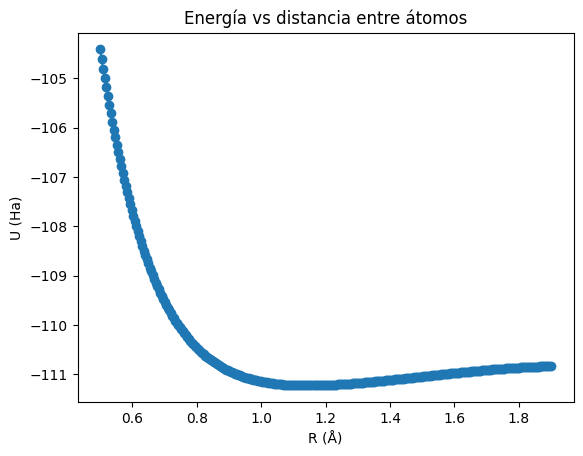

In [ ]:
plot(R,U,'o-')
plt.title('Energía vs distancia entre átomos')
xlabel('R (Å)')
ylabel('U (Ha)')

#Nueva parte del script
plt.savefig("EvsR.png")

## Aproximación a una parábola de $U$

In [ ]:
# En U tenemos guardados los datos calculados
# y en R las separaciones entre los núcleos

# Nos preguntamos, ¿cuál es el valor más pequeño de U?
# Es decir, en la separación de equilibrio cuál es su energía
print( min(U), "(Ha)" )

# Guardamos el valor de U en el equilibrio
Ueq = min(U)

-111.22544333412432 (Ha)


In [ ]:
# Nos preguntamos, ¿a qué distancia se tiene el mínimo?
print( R[argmin(U)], "(Å)" )

# Guardamos la separación de equilibrio
Req = R[argmin(U)]

1.144 (Å)


In [ ]:
# Realicemos una aproximación a una parábola cerca del equilibrio,
# para lo cual necesitamos los valores cerca del equilibrio.

# Guardemos en qué índice del arreglo de datos tenemos el equilibrio
indice = argmin(U)

# Seleccionemos algunos valores de R y U cerca del equilibrio
valR = R[indice-3:indice+4]
valU = U[indice-3:indice+4]

# Utilizamos la función polyfit para obtener el ajuste a un polinomio
# de grado 2, ax²+bx+c
a,b,c = polyfit(valR,valU,2)

# a estará relacionado con la constante de resorte
# a = κ/2
# ¿cuáles son las unidade de a?

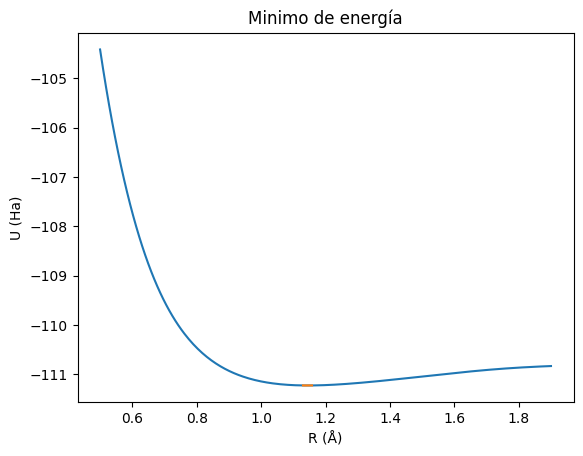

In [ ]:
# Visualicemos que tan adecuada es nuestra aproximación
plot(R,U)
plot(valR,a*valR*valR+b*valR+c)
# Ajustamos los límites de graficación para visualizar mejor
# la aproximación a una parábola. Note, que si cambia la
# separación de equilibrio, entonces tendría que cambiar
# las siguientes dos instrucciones del código.
#xlim(0.5,1.0)
#ylim(-1.2,-1.0)

#Nueva parte del script
plt.title('Minimo de energía')
xlabel('R (Å)')
ylabel('U (Ha)')
plt.savefig("ME.png")

In [ ]:
# Calculemos κ en unidades del sistema internacional,
# entonces tenemos que cambiar la energía a Joule
# y Å a metros.
#
# κ = 2a

Ha_to_J  = 4.3597439422e-18
Å_to_m = 1e-10
κ = 2*a*Ha_to_J/Å_to_m/Å_to_m

print(κ, "N/m")

2474.5792463846315 N/m


## Energías vibracionales

$$
E_{\rm vib}=\hbar \omega \bigg(n+\frac{1}{2}\bigg)
$$

Calculemos las energías vibracionales para $n=0,1,2,3$ en unidades de ${\rm eV}$.

$$
\omega = \sqrt{\frac{\kappa}{\mu}}
$$

donde la masa esta dada por
$$
\mu=\frac{m_\alpha m_\beta}{m_\alpha + m_\beta}
$$

In [ ]:
# Escribamos las masas en uma
mC_uma = 12.011
mO_uma = 15.9994
# Determinemos la masa reducida en uma
μ_uma  = (mC_uma*mO_uma)/(mC_uma+mO_uma)

# Convirtamos la masa reducida a kilogramos
NA     = 6.02214076e23
μ_kg   = μ_uma/NA

# Determinemos ω en unidades del sistema internacional
ω      = sqrt(κ/μ_kg)

# Determinemos el valor de ħω en unidades del SI, por
# lo cual necesitamos del valor de ħ en el SI
ħ      = 1.05457182e-34
ħω     = ħ*ω
print(f"ħω = {ħω} (J)" )

# Convirtamos las energías de Joule a eV
e      = 1.602e-19
ħω_eV  = ħω/e
print(f"ħω = {ħω_eV} (eV)" )

# Determinemos los niveles de energía en eV

# n = 0
Evib0 = ħω_eV/2
print("n = 0:",Evib0," (eV)")

# n = 1
Evib1 = 3*ħω_eV/2
print("n = 1:",Evib1," (eV)")

# n = 2
Evib2 = 5*ħω_eV/2
print("n = 2:",Evib2," (eV)")

# n = 3
Evib3 = 7*ħω_eV/2
print("n = 3:",Evib3," (eV)")

ħω = 1.5542487262772881e-21 (J)
ħω = 0.009701927130320151 (eV)
n = 0: 0.004850963565160076  (eV)
n = 1: 0.014552890695480228  (eV)
n = 2: 0.024254817825800377  (eV)
n = 3: 0.03395674495612053  (eV)
